<a href="https://colab.research.google.com/github/surya-X-13/Mobile-Price-Predictor-/blob/main/Mobile_Price.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [225]:
import kagglehub
path = kagglehub.dataset_download("iabhishekofficial/mobile-price-classification")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'mobile-price-classification' dataset.
Path to dataset files: /kaggle/input/mobile-price-classification


In [226]:
import os
import pandas as pd

file_names = os.listdir(path)
print(f"Files in the dataset directory: {file_names}")

train_file = None
test_file = None

for f in file_names:
    if f.lower() == 'train.csv':
        train_file = os.path.join(path, f)
    elif f.lower() == 'test.csv':
        test_file = os.path.join(path, f)

if train_file and test_file:
    train_df = pd.read_csv(train_file)
    test_df = pd.read_csv(test_file)
    print("\nTraining data loaded successfully. Displaying the first 5 rows:")
    display(train_df.head())
    print("\nTesting data loaded successfully. Displaying the first 5 rows:")
    display(test_df.head())
elif train_file:
    print(f"Found 'train.csv' but not 'test.csv'. Loading 'train.csv' into train_df.")
    train_df = pd.read_csv(train_file)
    display(train_df.head())
elif test_file:
    print(f"Found 'test.csv' but not 'train.csv'. Loading 'test.csv' into test_df.")
    test_df = pd.read_csv(test_file)
    display(test_df.head())
else:
    print("Neither 'train.csv' nor 'test.csv' found in the dataset directory. Please check the file types.")


if 'df' in locals():
    del df

Files in the dataset directory: ['train.csv', 'test.csv']

Training data loaded successfully. Displaying the first 5 rows:


,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1



Testing data loaded successfully. Displaying the first 5 rows:


,id,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,...,pc,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi
0,1,1043,1,1.8,1,14,0,5,0.1,193,...,16,226,1412,3476,12,7,2,0,1,0
1,2,841,1,0.5,1,4,1,61,0.8,191,...,12,746,857,3895,6,0,7,1,0,0
2,3,1807,1,2.8,0,1,0,27,0.9,186,...,4,1270,1366,2396,17,10,10,0,1,1
3,4,1546,0,0.5,1,18,1,25,0.5,96,...,20,295,1752,3893,10,0,7,1,1,0
4,5,1434,0,1.4,0,11,1,49,0.5,108,...,18,749,810,1773,15,8,7,1,0,1


In [227]:
train_df.head()

,battery_power,blue,clock_speed,dual_sim,fc,four_g,int_memory,m_dep,mobile_wt,n_cores,...,px_height,px_width,ram,sc_h,sc_w,talk_time,three_g,touch_screen,wifi,price_range
0,842,0,2.2,0,1,0,7,0.6,188,2,...,20,756,2549,9,7,19,0,0,1,1
1,1021,1,0.5,1,0,1,53,0.7,136,3,...,905,1988,2631,17,3,7,1,1,0,2
2,563,1,0.5,1,2,1,41,0.9,145,5,...,1263,1716,2603,11,2,9,1,1,0,2
3,615,1,2.5,0,0,0,10,0.8,131,6,...,1216,1786,2769,16,8,11,1,0,0,2
4,1821,1,1.2,0,13,1,44,0.6,141,2,...,1208,1212,1411,8,2,15,1,1,0,1


In [228]:
train_df.shape

(2000, 21)

In [229]:
test_df.shape

(1000, 21)

In [230]:
train_df.columns

Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='object')

In [231]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000 entries, 0 to 1999
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   battery_power  2000 non-null   int64  
 1   blue           2000 non-null   int64  
 2   clock_speed    2000 non-null   float64
 3   dual_sim       2000 non-null   int64  
 4   fc             2000 non-null   int64  
 5   four_g         2000 non-null   int64  
 6   int_memory     2000 non-null   int64  
 7   m_dep          2000 non-null   float64
 8   mobile_wt      2000 non-null   int64  
 9   n_cores        2000 non-null   int64  
 10  pc             2000 non-null   int64  
 11  px_height      2000 non-null   int64  
 12  px_width       2000 non-null   int64  
 13  ram            2000 non-null   int64  
 14  sc_h           2000 non-null   int64  
 15  sc_w           2000 non-null   int64  
 16  talk_time      2000 non-null   int64  
 17  three_g        2000 non-null   int64  
 18  touch_sc

In [232]:
print(train_df.columns)
print(test_df.columns)

Index(['battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc', 'four_g',
       'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc', 'px_height',
       'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi', 'price_range'],
      dtype='object')
Index(['id', 'battery_power', 'blue', 'clock_speed', 'dual_sim', 'fc',
       'four_g', 'int_memory', 'm_dep', 'mobile_wt', 'n_cores', 'pc',
       'px_height', 'px_width', 'ram', 'sc_h', 'sc_w', 'talk_time', 'three_g',
       'touch_screen', 'wifi'],
      dtype='object')


In [233]:
test_df.drop('id', axis=1, inplace=True)

In [234]:
test_df.shape

(1000, 20)

In [235]:
train_df.isnull().sum()

,0
battery_power,0
blue,0
clock_speed,0
dual_sim,0
fc,0
four_g,0
int_memory,0
m_dep,0
mobile_wt,0
n_cores,0


In [236]:
train_df["price_range"]

,price_range
0,1
1,2
2,2
3,2
4,1
...,...
1995,0
1996,2
1997,3
1998,0


In [237]:
from sklearn.model_selection import train_test_split
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='price_range', ylabel='battery_power'>

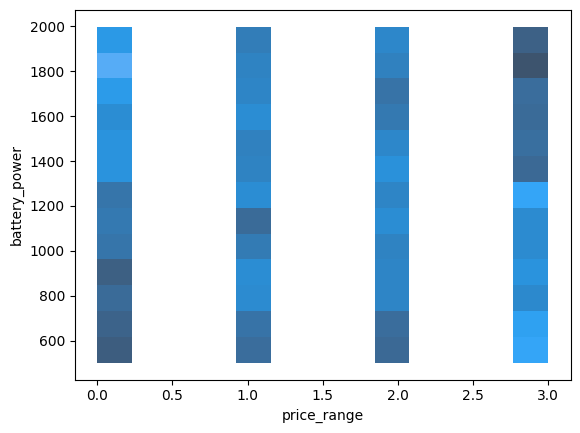

In [238]:
sns.histplot(data=train_df, y="battery_power",x="price_range")

In [239]:
X = train_df.drop('price_range', axis=1)
y = train_df['price_range']

In [240]:
X_train, X_test, y_train, y_test = train_test_split(X,y, test_size=0.2, random_state=42)

Correlation of features with 'price_range':
 price_range      1.000000
ram              0.917046
battery_power    0.200723
px_width         0.165818
px_height        0.148858
int_memory       0.044435
sc_w             0.038711
pc               0.033599
three_g          0.023611
sc_h             0.022986
fc               0.021998
talk_time        0.021859
blue             0.020573
wifi             0.018785
dual_sim         0.017444
four_g           0.014772
n_cores          0.004399
m_dep            0.000853
clock_speed     -0.006606
mobile_wt       -0.030302
touch_screen    -0.030411
Name: price_range, dtype: float64


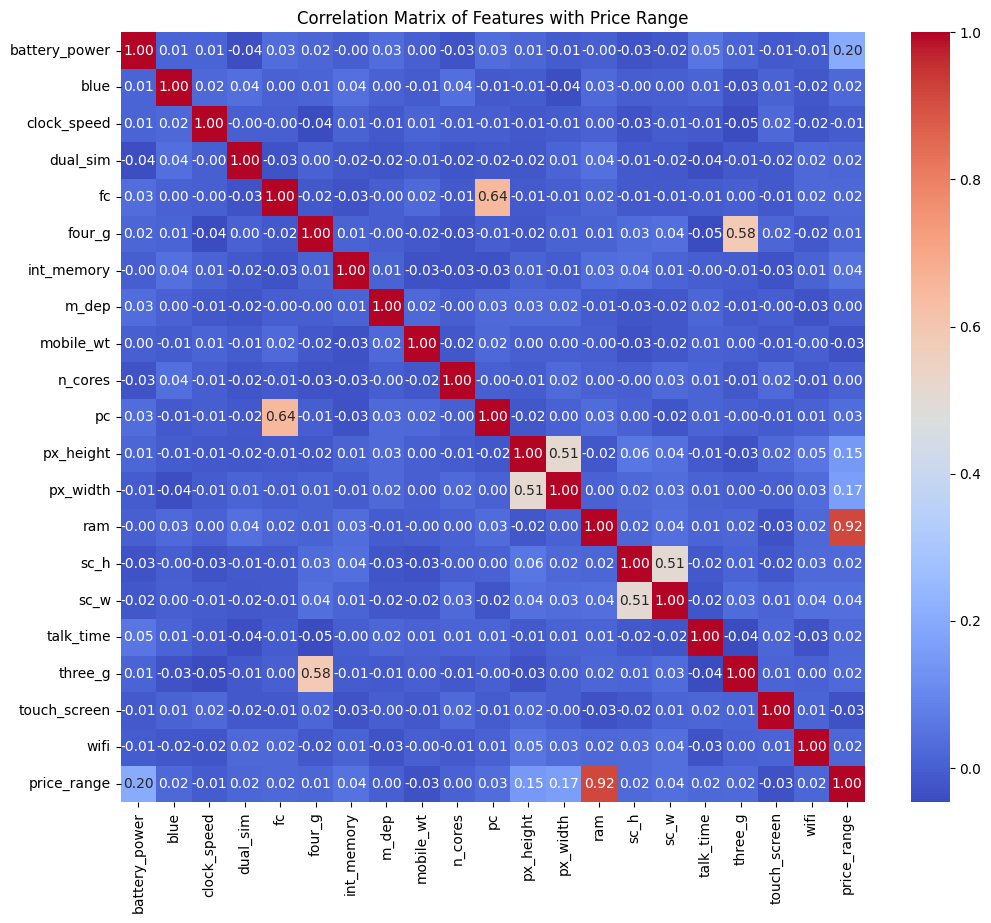

In [241]:
import matplotlib.pyplot as plt
import seaborn as sns

corr_matrix = train_df.corr()

price_range_corr = corr_matrix['price_range'].sort_values(ascending=False)
print("Correlation of features with 'price_range':\n", price_range_corr)

plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Matrix of Features with Price Range')
plt.show()

In [242]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report

In [243]:
result = []

In [244]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [245]:
log_reg = LogisticRegression()
log_reg.fit(X_train_scaled,y_train)
y_pred = log_reg.predict(X_test_scaled)
recall_score_log_reg = recall_score(y_test, y_pred, average='weighted')
precision_score_log_reg = precision_score(y_test, y_pred, average='weighted')
f1_score_log_reg = f1_score(y_test, y_pred, average='weighted')
accuracy_score_log_reg = accuracy_score(y_test, y_pred)
named_log_reg_metrics = {
    "Model": "Logistic Regression (Initial Run)",
    "Recall": recall_score_log_reg,
    "Precision": precision_score_log_reg,
    "F1-Score": f1_score_log_reg,
    "Accuracy": accuracy_score_log_reg
}
result.append(named_log_reg_metrics)

In [246]:
result

[{'Model': 'Logistic Regression (Initial Run)',
  'Recall': 0.975,
  'Precision': 0.9759457776352783,
  'F1-Score': 0.9750198554444309,
  'Accuracy': 0.975}]

In [247]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
y_pred = dt.predict(X_test)
recall_score_dt = recall_score(y_test, y_pred, average='weighted')
precision_score_dt = precision_score(y_test, y_pred, average='weighted')
f1_score_dt = f1_score(y_test, y_pred, average='weighted')
accuracy_score_dt = accuracy_score(y_test, y_pred)
named_dt_metrics = {
    "Model": "Decision Tree Classifier (Initial Run)",
    "Recall": recall_score_dt,
    "Precision": precision_score_dt,
    "F1-Score": f1_score_dt,
    "Accuracy": accuracy_score_dt
}
result.append(named_dt_metrics)

In [248]:
result

[{'Model': 'Logistic Regression (Initial Run)',
  'Recall': 0.975,
  'Precision': 0.9759457776352783,
  'F1-Score': 0.9750198554444309,
  'Accuracy': 0.975},
 {'Model': 'Decision Tree Classifier (Initial Run)',
  'Recall': 0.8,
  'Precision': 0.8085600679704871,
  'F1-Score': 0.8031160908252253,
  'Accuracy': 0.8}]

In [249]:
# 1. Random Forest Classifier
rf_clf = RandomForestClassifier(random_state=42)
rf_clf.fit(X_train, y_train)
y_pred_rf = rf_clf.predict(X_test)
rf_metrics = {
    "Model": "Random Forest Classifier (Initial Run)",
    "Recall": recall_score(y_test, y_pred_rf, average='weighted'),
    "Precision": precision_score(y_test, y_pred_rf, average='weighted'),
    "F1-Score": f1_score(y_test, y_pred_rf, average='weighted'),
    "Accuracy": accuracy_score(y_test, y_pred_rf)
}
result.append(rf_metrics)

# 2. Support Vector Classifier (SVC)
svc_clf = SVC(random_state=42)
svc_clf.fit(X_train_scaled, y_train)
y_pred_svc = svc_clf.predict(X_test_scaled)
svc_metrics = {
    "Model": "SVC (Initial Run)",
    "Recall": recall_score(y_test, y_pred_svc, average='weighted'),
    "Precision": precision_score(y_test, y_pred_svc, average='weighted'),
    "F1-Score": f1_score(y_test, y_pred_svc, average='weighted'),
    "Accuracy": accuracy_score(y_test, y_pred_svc)
}
result.append(svc_metrics)

# 3. K-Nearest Neighbors Classifier (KNN)
knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train_scaled, y_train)
y_pred_knn = knn_clf.predict(X_test_scaled)
knn_metrics = {
    "Model": "K-Nearest Neighbors (Initial Run)",
    "Recall": recall_score(y_test, y_pred_knn, average='weighted'),
    "Precision": precision_score(y_test, y_pred_knn, average='weighted'),
    "F1-Score": f1_score(y_test, y_pred_knn, average='weighted'),
    "Accuracy": accuracy_score(y_test, y_pred_knn)
}
result.append(knn_metrics)

# 4. Gradient Boosting Classifier
gbc_clf = GradientBoostingClassifier(random_state=42)
gbc_clf.fit(X_train, y_train)
y_pred_gbc = gbc_clf.predict(X_test)
gbc_metrics = {
    "Model": "Gradient Boosting Classifier (Initial Run)",
    "Recall": recall_score(y_test, y_pred_gbc, average='weighted'),
    "Precision": precision_score(y_test, y_pred_gbc, average='weighted'),
    "F1-Score": f1_score(y_test, y_pred_gbc, average='weighted'),
    "Accuracy": accuracy_score(y_test, y_pred_gbc)
}
result.append(gbc_metrics)

In [250]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [251]:
xgb_clf = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='mlogloss')
xgb_clf.fit(X_train, y_train)
y_pred_xgb = xgb_clf.predict(X_test)

xgb_metrics = {
    "Model": "XGBoost Classifier (Initial Run)",
    "Recall": recall_score(y_test, y_pred_xgb, average='weighted'),
    "Precision": precision_score(y_test, y_pred_xgb, average='weighted'),
    "F1-Score": f1_score(y_test, y_pred_xgb, average='weighted'),
    "Accuracy": accuracy_score(y_test, y_pred_xgb)
}
result.append(xgb_metrics)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:39:21] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


In [252]:
from sklearn.ensemble import AdaBoostClassifier

In [253]:
adb_clf = AdaBoostClassifier(random_state=42)
adb_clf.fit(X_train, y_train)
y_pred_adb = adb_clf.predict(X_test)


adb_metrics = {
    "Model": "AdaBoost Classifier (Initial Run)",
    "Recall": recall_score(y_test, y_pred_adb, average='weighted'),
    "Precision": precision_score(y_test, y_pred_adb, average='weighted'),
    "F1-Score": f1_score(y_test, y_pred_adb, average='weighted'),
    "Accuracy": accuracy_score(y_test, y_pred_adb)
}
result.append(adb_metrics)



In [254]:
result_df = pd.DataFrame(result)
result_df

,Model,Recall,Precision,F1-Score,Accuracy
0,Logistic Regression (Initial Run),0.9750,0.975946,0.975020,0.9750
1,Decision Tree Classifier (Initial Run),0.8000,0.808560,0.803116,0.8000
2,Random Forest Classifier (Initial Run),0.8925,0.896138,0.893340,0.8925
3,SVC (Initial Run),0.8925,0.895561,0.893296,0.8925
4,K-Nearest Neighbors (Initial Run),0.5300,0.569762,0.540707,0.5300
5,Gradient Boosting Classifier (Initial Run),0.9050,0.906446,0.905496,0.9050
6,XGBoost Classifier (Initial Run),0.9050,0.906155,0.905007,0.9050
7,AdaBoost Classifier (Initial Run),0.7150,0.708925,0.708761,0.7150


In [255]:
best_model_df = result_df.sort_values(by='Accuracy', ascending=False)
display(best_model_df)

,Model,Recall,Precision,F1-Score,Accuracy
0,Logistic Regression (Initial Run),0.9750,0.975946,0.975020,0.9750
5,Gradient Boosting Classifier (Initial Run),0.9050,0.906446,0.905496,0.9050
6,XGBoost Classifier (Initial Run),0.9050,0.906155,0.905007,0.9050
2,Random Forest Classifier (Initial Run),0.8925,0.896138,0.893340,0.8925
3,SVC (Initial Run),0.8925,0.895561,0.893296,0.8925
1,Decision Tree Classifier (Initial Run),0.8000,0.808560,0.803116,0.8000
7,AdaBoost Classifier (Initial Run),0.7150,0.708925,0.708761,0.7150
4,K-Nearest Neighbors (Initial Run),0.5300,0.569762,0.540707,0.5300


In [257]:
from sklearn.ensemble import StackingClassifier


In [258]:
meta_model = LogisticRegression()
stacking_clf = StackingClassifier(
    estimators=[
        ('log_reg', log_reg),
        ('gbc_clf', gbc_clf),
        ('xgb_clf', xgb_clf),
    ],
    final_estimator=meta_model,
    cv=5
)

In [259]:
stacking_clf.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:39:25] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    ht

StackingClassifier(cv=5,
                   estimators=[('log_reg', LogisticRegression()),
                               ('gbc_clf',
                                GradientBoostingClassifier(random_state=42)),
                               ('xgb_clf',
                                XGBClassifier(base_score=None, booster=None,
                                              callbacks=None,
                                              colsample_bylevel=None,
                                              colsample_bynode=None,
                                              colsample_bytree=None,
                                              device=None,
                                              early_stopping_rounds=None,
                                              enable_categorical=False,
                                              eval_metric='mlogloss',
                                              fe...
                                              importance_type=None,
                                              interaction_constraints=None,
                                              learning_rate=None, max_bin=None,
                                              max_cat_threshold=None,
                                              max_cat_to_onehot=None,
                                              max_delta_step=None,
                                              max_depth=None, max_leaves=None,
                                              min_child_weight=None,
                                              missing=nan,
                                              monotone_constraints=None,
                                              multi_strategy=None,
                                              n_estimators=None, n_jobs=None,
                                              num_parallel_tree=None, ...))],
                   final_estimator=LogisticRegression())

In [260]:
y_pred_stack = stacking_clf.predict(X_test)

In [261]:
print(recall_score(y_test,y_pred_stack,average="weighted"))

0.915


In [262]:
from sklearn.pipeline import Pipeline

meta_model_fixed = LogisticRegression(max_iter=1000, random_state=42)

log_reg_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('log_reg', LogisticRegression(max_iter=1000, random_state=42))
])

stacking_clf_fixed = StackingClassifier(
    estimators=[
        ('log_reg_pipe', log_reg_pipeline),
        ('gbc_clf', gbc_clf),
        ('xgb_clf', xgb_clf)
    ],
    final_estimator=meta_model_fixed,
    cv=5
)
stacking_clf_fixed.fit(X_train, y_train)
print("StackingClassifier with fixed Logistic Regression pipeline and meta-model trained.")

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:39:42] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:39:55] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:39:55] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:39:56] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [18:39:56] WARNING: /w

StackingClassifier with fixed Logistic Regression pipeline and meta-model trained.


**Reasoning**:
The previous code block successfully trained the `stacking_clf_fixed` model. Now, I need to evaluate its performance (recall, precision, F1-score, accuracy) and add these metrics to the `result` list, then update and display the `result_df` as per the task instructions.



In [263]:
y_pred_stack_fixed = stacking_clf_fixed.predict(X_test)

stacking_metrics_fixed = {
    "Model": "StackingClassifier (Fixed)",
    "Recall": recall_score(y_test, y_pred_stack_fixed, average='weighted'),
    "Precision": precision_score(y_test, y_pred_stack_fixed, average='weighted'),
    "F1-Score": f1_score(y_test, y_pred_stack_fixed, average='weighted'),
    "Accuracy": accuracy_score(y_test, y_pred_stack_fixed)
}
result.append(stacking_metrics_fixed)



In [264]:
param_grid_lr = {
    'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag', 'saga'],
    'C': [0.01, 0.1, 1, 10, 100],
    'max_iter': [5000]
}


In [265]:
from sklearn.model_selection import GridSearchCV

In [266]:
log_reg_tuned = LogisticRegression(random_state=42)
grid_search_lr = GridSearchCV(estimator=log_reg_tuned, param_grid=param_grid_lr, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)


In [267]:
grid_search_lr.fit(X_train_scaled, y_train)


Fitting 5 folds for each of 25 candidates, totalling 125 fits


GridSearchCV(cv=5, estimator=LogisticRegression(random_state=42), n_jobs=-1,
             param_grid={'C': [0.01, 0.1, 1, 10, 100], 'max_iter': [5000],
                         'solver': ['newton-cg', 'lbfgs', 'liblinear', 'sag',
                                    'saga']},
             scoring='accuracy', verbose=1)

In [268]:
best_params_lr = grid_search_lr.best_params_
print("Best hyperparameters found for Logistic Regression:")
print(best_params_lr)

Best hyperparameters found for Logistic Regression:
{'C': 100, 'max_iter': 5000, 'solver': 'lbfgs'}


In [269]:
log_reg_tuned_model = LogisticRegression(**best_params_lr, random_state=42)
log_reg_tuned_model.fit(X_train_scaled, y_train)
y_pred_tuned_lr = log_reg_tuned_model.predict(X_test_scaled)

tuned_lr_metrics = {
    "Model": "Logistic Regression (Tuned)",
    "Recall": recall_score(y_test, y_pred_tuned_lr, average='weighted'),
    "Precision": precision_score(y_test, y_pred_tuned_lr, average='weighted'),
    "F1-Score": f1_score(y_test, y_pred_tuned_lr, average='weighted'),
    "Accuracy": accuracy_score(y_test, y_pred_tuned_lr)
}
result.append(tuned_lr_metrics)



In [270]:
result_df = pd.DataFrame(result)
display(result_df.sort_values(by='Accuracy', ascending=False))

,Model,Recall,Precision,F1-Score,Accuracy
0,Logistic Regression (Initial Run),0.9750,0.975946,0.975020,0.9750
9,Logistic Regression (Tuned),0.9750,0.976239,0.975065,0.9750
8,StackingClassifier (Fixed),0.9600,0.961013,0.959981,0.9600
5,Gradient Boosting Classifier (Initial Run),0.9050,0.906446,0.905496,0.9050
6,XGBoost Classifier (Initial Run),0.9050,0.906155,0.905007,0.9050
2,Random Forest Classifier (Initial Run),0.8925,0.896138,0.893340,0.8925
3,SVC (Initial Run),0.8925,0.895561,0.893296,0.8925
1,Decision Tree Classifier (Initial Run),0.8000,0.808560,0.803116,0.8000
7,AdaBoost Classifier (Initial Run),0.7150,0.708925,0.708761,0.7150
4,K-Nearest Neighbors (Initial Run),0.5300,0.569762,0.540707,0.5300


In [273]:
stacking_clf_2 = StackingClassifier(
    estimators=[
        ('log_reg', log_reg),
        ('log_reg_tuned', log_reg_tuned_model),
        ('stack_clf_fixed',stacking_clf_fixed)
        ],
    final_estimator=meta_model_fixed,
    cv=5
)

stacking_clf_2.fit(X_train, y_train)
y_pred_stack_2 = stacking_clf_2.predict(X_test)
print(recall_score(y_test,y_pred_stack_2,average="weighted"))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _c

0.955


In [274]:
final_scaler = StandardScaler()
X_scaled_full = final_scaler.fit_transform(X)

best_logistic_model = LogisticRegression(**best_params_lr, random_state=42)
best_logistic_model.fit(X_scaled_full, y)

print("Best Logistic Regression model retrained successfully on the entire dataset.")

Best Logistic Regression model retrained successfully on the entire dataset.


In [275]:
import pickle
model_filename = 'best_logistic_model.pkl'
with open(model_filename, 'wb') as file:
    pickle.dump(best_logistic_model, file)
scaler_filename = 'final_scaler.pkl'
with open(scaler_filename, 'wb') as file:
    pickle.dump(final_scaler, file)

print(f"Best Logistic Regression model saved to {model_filename}")
print(f"Final StandardScaler saved to {scaler_filename}")

Best Logistic Regression model saved to best_logistic_model.pkl
Final StandardScaler saved to final_scaler.pkl
